# Step 3b: Label Quality Audit

Before training a classifier (notebook 04), we need to check: **do the metadata labels actually match the free text?**

We're comparing:
- `areas_of_focus` (list of label strings) vs `description` (free text)
- `target_populations` (slash-delimited string) vs `eligibility` (free text)

Two methods:
1. **Keyword matching** — do label terms literally appear in the text?
2. **Embedding similarity** — are they semantically related? (catches synonyms)

In [1]:
!pip install sentence-transformers scipy -q

## Load and Prepare Data

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

with open('../data/homeless_services_hackathon.json', 'r') as f:
    services = json.load(f)

df = pd.DataFrame(services)
print(f"Loaded {len(df)} services")

Loaded 1719 services


In [3]:
# Look at the four fields we're comparing
s = df.iloc[0]
print(f"areas_of_focus ({len(s['areas_of_focus'])} items): {s['areas_of_focus'][:4]}...")
print(f"\ntarget_populations: {s['target_populations']}")
print(f"\ndescription: {s['description'][:200]}...")
print(f"\neligibility: {s['eligibility']}")

areas_of_focus (17 items): ['Youth Shelters', 'Personal', 'Grooming Supplies', 'Ongoing Emergency Food Assistance']...

target_populations: Homeless Youth/Runaway/Youth Shelter Residents/

description: Offers an interim shelter program that provides shelter for homeless youth who need a bed and food in a trauma-informed environment. 

Offers the following once enlisted: 
•	Food
•	Hygiene supplies
•	...

eligibility: Must be 18-24 years old, currently homeless, living at a temporary shelter or institution, or at risk of experiencing homelessness


In [4]:
# Known truncated/fragment values from data extraction
KNOWN_TRUNCATED = {'Case', 'First', 'Last', 'Personal', 'Landlord',
                   'Placement', 'Shelter', 'Prevention', 'Runaway', 'Formula', 'Spouse'}


def clean_areas_of_focus(aof_list):
    """Deduplicate and flag truncated values."""
    if not isinstance(aof_list, list):
        return [], [], 0
    seen, cleaned, truncated, dups = set(), [], [], 0
    for item in aof_list:
        key = item.strip().lower()
        if key in seen:
            dups += 1
            continue
        seen.add(key)
        cleaned.append(item.strip())
        if item.strip() in KNOWN_TRUNCATED:
            truncated.append(item.strip())
    return cleaned, truncated, dups


def parse_target_populations(tp_string):
    """Split slash-delimited target_populations, remove empties."""
    if not tp_string or pd.isna(tp_string) or str(tp_string).strip() == '':
        return []
    return [s.strip() for s in str(tp_string).split('/') if s.strip()]


# Apply to all services
clean_results = df['areas_of_focus'].apply(clean_areas_of_focus)
df['aof_cleaned'] = clean_results.apply(lambda x: x[0])
df['aof_truncated'] = clean_results.apply(lambda x: x[1])
df['aof_dup_count'] = clean_results.apply(lambda x: x[2])
df['tp_parsed'] = df['target_populations'].apply(parse_target_populations)
df['aof_count'] = df['aof_cleaned'].apply(len)
df['tp_count'] = df['tp_parsed'].apply(len)
df['desc_length'] = df['description'].apply(lambda x: len(str(x)) if x else 0)
df['elig_length'] = df['eligibility'].apply(lambda x: len(str(x)) if x else 0)

In [5]:
# Data quality issues at a glance
issues = pd.DataFrame({
    'Issue': ['Truncated AoF values', 'Duplicate AoF entries',
              'Empty target_populations', 'Short descriptions (<50 chars)',
              'Short eligibility (<20 chars)'],
    'Count': [(df['aof_truncated'].apply(len) > 0).sum(),
              (df['aof_dup_count'] > 0).sum(),
              (df['tp_count'] == 0).sum(),
              (df['desc_length'] < 50).sum(),
              (df['elig_length'] < 20).sum()]
})
issues['%'] = (issues['Count'] / len(df) * 100).round(1)
print(issues.to_string(index=False))

# Most common truncated values
all_trunc = [v for vals in df['aof_truncated'] for v in vals]
print(f"\nTop truncated values: {Counter(all_trunc).most_common(5)}")

                         Issue  Count    %
          Truncated AoF values    398 23.2
         Duplicate AoF entries     68  4.0
      Empty target_populations    340 19.8
Short descriptions (<50 chars)      3  0.2
 Short eligibility (<20 chars)    289 16.8

Top truncated values: [('Case', 151), ('Prevention', 72), ('Formula', 58), ('Shelter', 57), ('Personal', 35)]


## Method 1: Keyword Matching

For each service: what % of `areas_of_focus` terms appear in `description`? Same for `target_populations` vs `eligibility`.

This misses synonyms ("shelter" vs "housing") but gives a fast baseline.

In [6]:
STOPWORDS = {'and', 'or', 'the', 'of', 'for', 'in', 'to', 'a', 'an', 'is', 'are', 'at', 'by', 'on', 'with'}


def keyword_overlap_score(label_terms, text):
    """
    What fraction of label terms appear (case-insensitive) in the text?
    Checks full phrase first, then falls back to individual significant words.
    """
    if not label_terms or not text:
        return np.nan
    text_lower = str(text).lower()
    matched = 0
    eligible = 0
    for term in label_terms:
        if len(term.strip()) < 3:
            continue
        eligible += 1
        term_lower = term.strip().lower()
        if term_lower in text_lower:
            matched += 1
        else:
            words = [w for w in term_lower.split() if w not in STOPWORDS and len(w) > 2]
            if any(w in text_lower for w in words):
                matched += 1
    return matched / eligible if eligible > 0 else np.nan


df['aof_kw_score'] = df.apply(lambda r: keyword_overlap_score(r['aof_cleaned'], r['description']), axis=1)
df['tp_kw_score'] = df.apply(lambda r: keyword_overlap_score(r['tp_parsed'], r['eligibility']), axis=1)

print(f"AoF vs Description:  mean={df['aof_kw_score'].mean():.2f}, median={df['aof_kw_score'].median():.2f}")
print(f"TP vs Eligibility:   mean={df['tp_kw_score'].mean():.2f}, median={df['tp_kw_score'].median():.2f}")

AoF vs Description:  mean=0.79, median=0.88
TP vs Eligibility:   mean=0.55, median=0.50


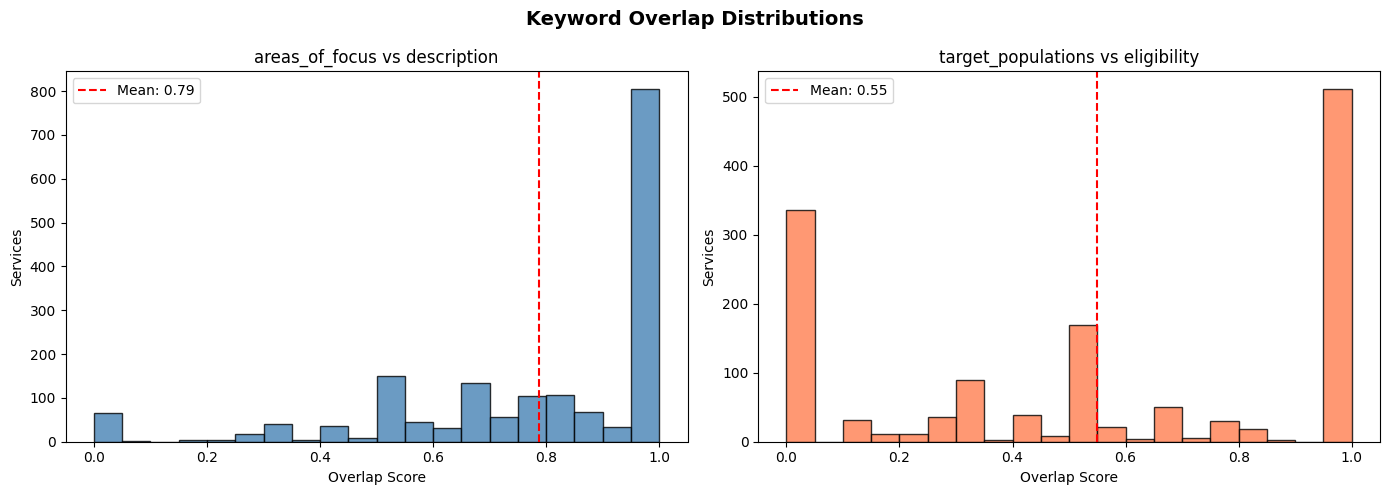

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['aof_kw_score'].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['aof_kw_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['aof_kw_score'].mean():.2f}")
axes[0].set_xlabel('Overlap Score')
axes[0].set_ylabel('Services')
axes[0].set_title('areas_of_focus vs description')
axes[0].legend()

axes[1].hist(df['tp_kw_score'].dropna(), bins=20, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(df['tp_kw_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['tp_kw_score'].mean():.2f}")
axes[1].set_xlabel('Overlap Score')
axes[1].set_ylabel('Services')
axes[1].set_title('target_populations vs eligibility')
axes[1].legend()

plt.suptitle('Keyword Overlap Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Low-overlap examples: where labels DON'T match the text
low_aof = df[df['aof_kw_score'].notna() & (df['aof_kw_score'] == 0)].head(3)
print("Examples: AoF labels with 0% keyword match to description")
print("-" * 70)
for _, row in low_aof.iterrows():
    print(f"\n{row['service_name']}")
    print(f"  AoF labels: {row['aof_cleaned']}")
    print(f"  Description: {str(row['description'])[:150]}...")

Examples: AoF labels with 0% keyword match to description
----------------------------------------------------------------------

TAY Rapid Re-housing Program
  AoF labels: ['Rapid Re-Housing Programs']
  Description: Provides assistance in helping participants ages 18-24 who are experiencing homelessness quickly return to housing through case management and financi...

Adjoin Veterans SSVF Rapid Re-Housing, San Diego
  AoF labels: ['Rapid Re-Housing Programs']
  Description: Provides temporary financial assistance, short-term rental support, case management, housing search assistance, and service referrals for Veterans and...

Rapid Re-housing Program
  AoF labels: ['Rapid Re-Housing Programs']
  Description: Offers rental assistance and security deposits as well as landlord advocacy, assistance with finding affordable housing and case management assistance...


## Method 2: Embedding Similarity

Keyword matching misses synonyms. "Community Shelters" won't keyword-match a description that says "safe shelter for persons experiencing homelessness" — but they mean the same thing.

We embed both texts with `all-MiniLM-L6-v2` and measure cosine similarity.

In [9]:
from sentence_transformers import SentenceTransformer
from numpy.linalg import norm
from tqdm import tqdm

model = SentenceTransformer('all-MiniLM-L6-v2')


def cosine_sim(a, b):
    if norm(a) == 0 or norm(b) == 0:
        return 0.0
    return float(np.dot(a, b) / (norm(a) * norm(b)))


# Prepare text: join label lists into comma-separated strings
df['aof_text'] = df['aof_cleaned'].apply(lambda x: ', '.join(x) if x else '')
df['tp_text'] = df['tp_parsed'].apply(lambda x: ', '.join(x) if x else '')

# Encode all four fields
def batch_encode(texts, desc="Encoding"):
    all_emb = []
    for i in tqdm(range(0, len(texts), 128), desc=desc):
        batch = [t if t.strip() else '[empty]' for t in texts[i:i+128]]
        all_emb.append(model.encode(batch, show_progress_bar=False))
    return np.vstack(all_emb)

desc_emb = batch_encode(df['description'].fillna('').tolist(), "Descriptions")
elig_emb = batch_encode(df['eligibility'].fillna('').tolist(), "Eligibility")
aof_emb = batch_encode(df['aof_text'].tolist(), "Areas of Focus")
tp_emb = batch_encode(df['tp_text'].tolist(), "Target Populations")

print(f"\nEmbeddings: {desc_emb.shape[1]}-dimensional")

Target Populations: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 15.24it/s]


Embeddings: 384-dimensional


In [10]:
# Compute cosine similarity for each service
df['sim_desc_aof'] = [cosine_sim(desc_emb[i], aof_emb[i]) for i in range(len(df))]
df['sim_elig_tp'] = [cosine_sim(elig_emb[i], tp_emb[i]) for i in range(len(df))]
df.loc[df['tp_count'] == 0, 'sim_elig_tp'] = np.nan  # NaN for empty TP

print(f"Desc <-> AoF:  mean={df['sim_desc_aof'].mean():.3f}")
print(f"Elig <-> TP:   mean={df['sim_elig_tp'].dropna().mean():.3f}")

Desc <-> AoF:  mean=0.571
Elig <-> TP:   mean=0.453


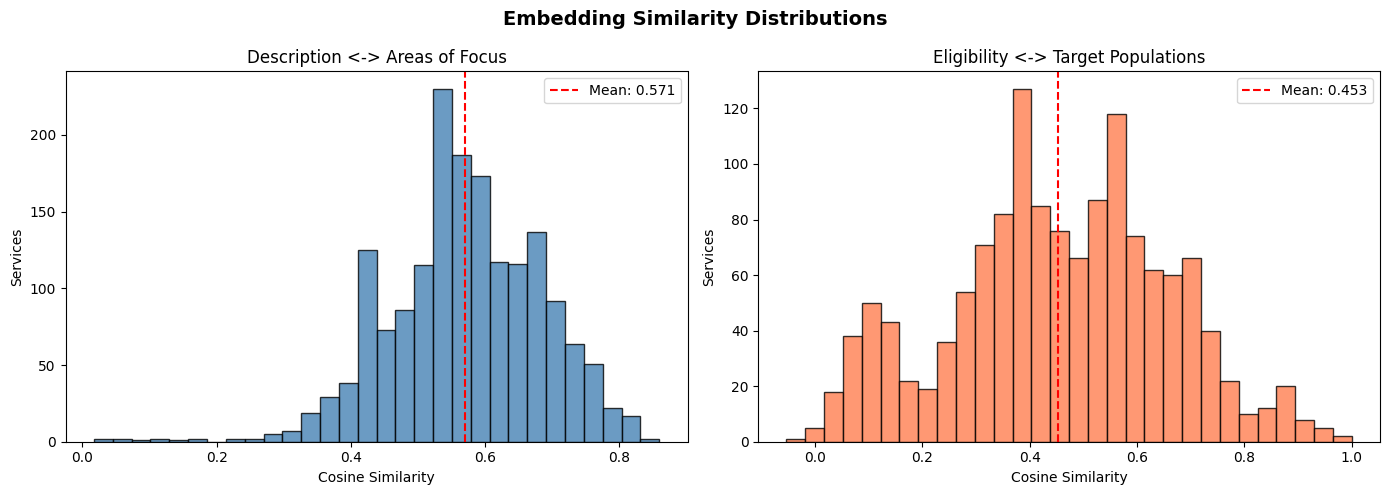

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sim_desc_aof'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['sim_desc_aof'].mean(), color='red', linestyle='--', label=f"Mean: {df['sim_desc_aof'].mean():.3f}")
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Services')
axes[0].set_title('Description <-> Areas of Focus')
axes[0].legend()

axes[1].hist(df['sim_elig_tp'].dropna(), bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(df['sim_elig_tp'].dropna().mean(), color='red', linestyle='--', label=f"Mean: {df['sim_elig_tp'].dropna().mean():.3f}")
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Services')
axes[1].set_title('Eligibility <-> Target Populations')
axes[1].legend()

plt.suptitle('Embedding Similarity Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

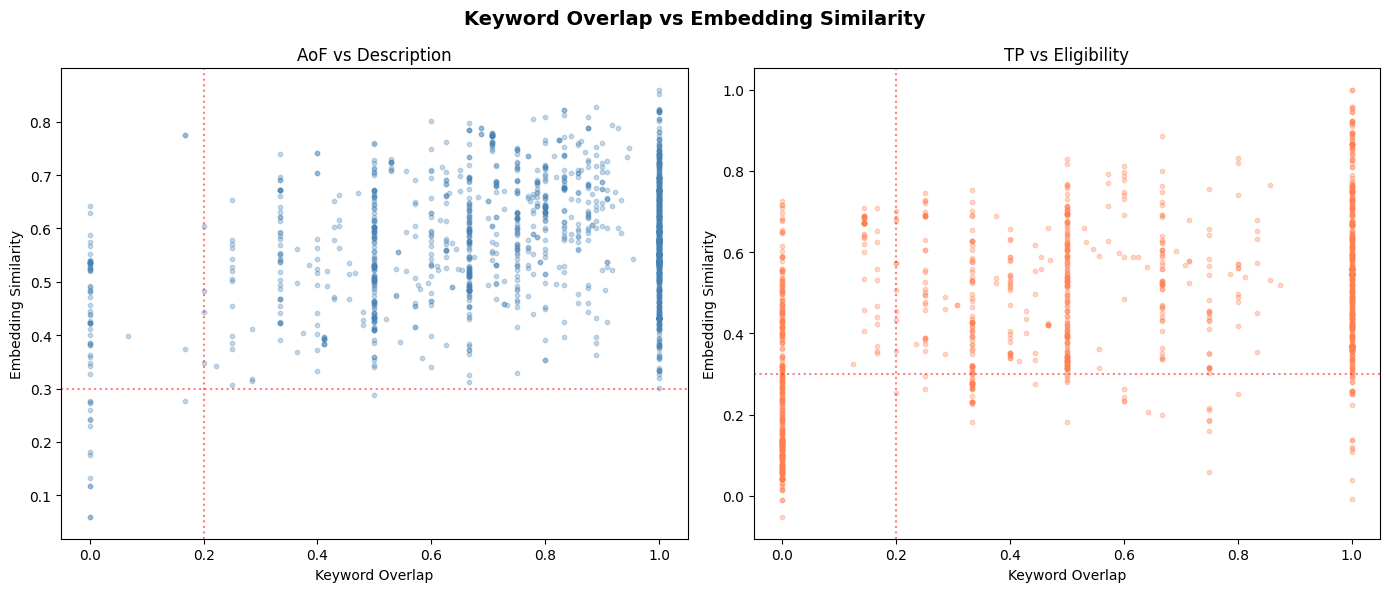

In [12]:
# Scatter: keyword vs embedding — do they agree?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mask = df['aof_kw_score'].notna()
axes[0].scatter(df.loc[mask, 'aof_kw_score'], df.loc[mask, 'sim_desc_aof'], alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Keyword Overlap')
axes[0].set_ylabel('Embedding Similarity')
axes[0].set_title('AoF vs Description')
axes[0].axhline(y=0.3, color='red', linestyle=':', alpha=0.5)
axes[0].axvline(x=0.2, color='red', linestyle=':', alpha=0.5)

mask_tp = df['tp_kw_score'].notna() & df['sim_elig_tp'].notna()
axes[1].scatter(df.loc[mask_tp, 'tp_kw_score'], df.loc[mask_tp, 'sim_elig_tp'], alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Keyword Overlap')
axes[1].set_ylabel('Embedding Similarity')
axes[1].set_title('TP vs Eligibility')
axes[1].axhline(y=0.3, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(x=0.2, color='red', linestyle=':', alpha=0.5)

plt.suptitle('Keyword Overlap vs Embedding Similarity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Cases where embedding catches what keywords miss (synonym matches)
synonym_matches = df[(df['aof_kw_score'] < 0.2) & (df['sim_desc_aof'] > 0.6)]
print(f"Low keyword but high embedding (synonyms): {len(synonym_matches)} services")
for _, row in synonym_matches.iterrows():
    print(f"\n  {row['service_name']} (KW={row['aof_kw_score']:.2f}, Emb={row['sim_desc_aof']:.3f})")
    print(f"    AoF: {row['aof_cleaned']}")
    print(f"    Desc: {str(row['description'])[:120]}...")

Low keyword but high embedding (synonyms): 4 services

  Standup for Kids, San Diego (KW=0.17, Emb=0.775)
    AoF: ['Homeless Drop In Centers', 'Street Outreach Programs', 'Public Showers', 'Baths', 'Laundry Facilities', 'Telephone Facilities', 'Temporary Mailing Address', 'General Legal Aid', 'Guidance and Counseling', 'Congregate Meals', 'Nutrition Sites', 'General Clothing Provision']
    Desc: Offers a drop in center for homeless teens, street outreach, mentoring, send a kid home program, snack and shower pogram...

  Harm Reduction Shelter (KW=0.00, Emb=0.629)
    AoF: ['Community Shelters']
    Desc: Provides a safe shelter and support services for individuals experiencing homelessness who have chronic substance use or...

  Rosecrans Bridge Shelter (KW=0.00, Emb=0.642)
    AoF: ['Community Shelters']
    Desc: Shelter offers a safe place for persons experiencing homelessness to receive shelter and appropriate services needed whi...

  Standup for Kids, San Diego (KW=0.17, Emb=0.

## Combined Quality Score & Findings

In [14]:
# Combine both signals: 40% keyword + 60% embedding
df['combined_quality'] = df.apply(
    lambda r: 0.4 * (r['aof_kw_score'] if pd.notna(r['aof_kw_score']) else 0.0) + 0.6 * r['sim_desc_aof'],
    axis=1
)

print(f"Combined quality: mean={df['combined_quality'].mean():.3f}")
print(f"Low quality (< 0.3):  {(df['combined_quality'] < 0.3).sum()} services ({(df['combined_quality'] < 0.3).mean()*100:.1f}%)")
print(f"High quality (> 0.7): {(df['combined_quality'] > 0.7).sum()} services ({(df['combined_quality'] > 0.7).mean()*100:.1f}%)")

Combined quality: mean=0.657
Low quality (< 0.3):  50 services (2.9%)
High quality (> 0.7): 854 services (49.7%)


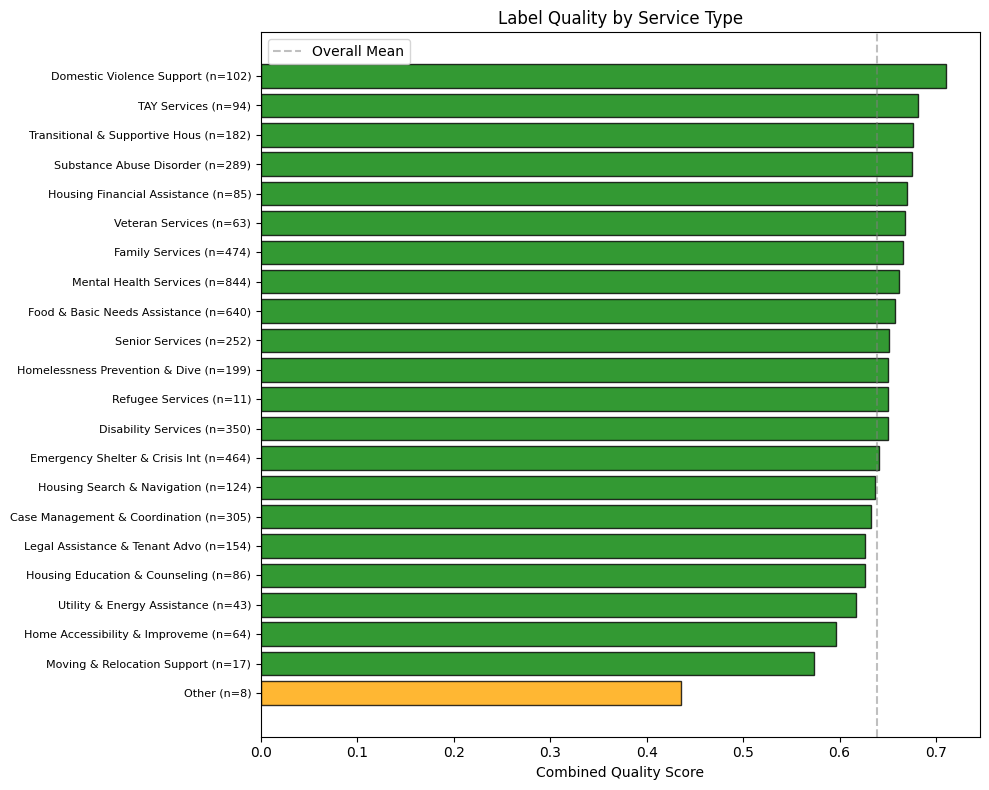

In [15]:
# Quality by service type
rows = []
for _, row in df.iterrows():
    for t in (row.get('types') or []):
        rows.append({'type': t, 'quality': row['combined_quality']})

type_avg = pd.DataFrame(rows).groupby('type')['quality'].agg(['mean', 'count']).sort_values('mean')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if m < 0.35 else 'orange' if m < 0.45 else 'green' for m in type_avg['mean']]
ax.barh(range(len(type_avg)), type_avg['mean'], color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(type_avg)))
ax.set_yticklabels([f"{t[:30]} (n={int(c)})" for t, c in zip(type_avg.index, type_avg['count'])], fontsize=8)
ax.set_xlabel('Combined Quality Score')
ax.set_title('Label Quality by Service Type')
ax.axvline(x=type_avg['mean'].mean(), color='gray', linestyle='--', alpha=0.5, label='Overall Mean')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# 15 most problematic services
worst = df.nsmallest(15, 'combined_quality')[['service_name', 'aof_kw_score', 'sim_desc_aof', 'combined_quality', 'aof_count']]
worst.columns = ['Service', 'Keyword', 'Embedding', 'Combined', 'AoF#']
print("Most Problematic Services:")
print(worst.to_string(index=False))

Most Problematic Services:
                                               Service  Keyword  Embedding  Combined  AoF#
Building Healthy Families: Family Urgent Response Team      NaN   0.017063  0.010238     0
                            School Based Mental Health      NaN   0.041653  0.024992     0
           Imperial Valley Narcotics Anonymous Hotline      0.0   0.058723  0.035234     2
                San Diego Narcotics Anonymous Helpline      0.0   0.058723  0.035234     2
                         Food Pantry, Cuyamaca College      NaN   0.080210  0.048126     0
                                   All Major Resources      0.0   0.116581  0.069949     1
                                   All Major Resources      0.0   0.116581  0.069949     1
              Food Distribution, San Diego Marketplace      0.0   0.132076  0.079245     1
           Men Drug and Alcohol Rehabilitation Program      0.0   0.176399  0.105839     2
               Alcohol and Drug Rehabilitation Program      0.0

In [17]:
# Do truncated AoF values correlate with lower quality?
from scipy.stats import mannwhitneyu

has_trunc = df[df['aof_truncated'].apply(len) > 0]['combined_quality']
no_trunc = df[df['aof_truncated'].apply(len) == 0]['combined_quality']

print(f"WITH truncated AoF:    avg quality = {has_trunc.mean():.3f} (n={len(has_trunc)})")
print(f"WITHOUT truncated AoF: avg quality = {no_trunc.mean():.3f} (n={len(no_trunc)})")

stat, p = mannwhitneyu(has_trunc, no_trunc, alternative='two-sided')
print(f"Mann-Whitney U: p={p:.4f} ({'significant' if p < 0.05 else 'not significant'})")

WITH truncated AoF:    avg quality = 0.629 (n=398)
WITHOUT truncated AoF: avg quality = 0.665 (n=1321)
Mann-Whitney U: p=0.0000 (significant)


## Summary

In [18]:
from IPython.display import Markdown

n = len(df)
aof_kw_mean = df['aof_kw_score'].mean()
aof_kw_med = df['aof_kw_score'].median()
tp_kw_mean = df['tp_kw_score'].mean()
tp_kw_med = df['tp_kw_score'].median()
sim_da = df['sim_desc_aof'].mean()
sim_et = df['sim_elig_tp'].dropna().mean()
n_empty_tp = (df['tp_count'] == 0).sum()
n_trunc = (df['aof_truncated'].apply(len) > 0).sum()
n_low = (df['combined_quality'] < 0.3).sum()
n_high = (df['combined_quality'] > 0.7).sum()
combined_mean = df['combined_quality'].mean()

summary = f"""### Key Findings

| Metric | Value |
|--------|-------|
| AoF keyword overlap (mean / median) | {aof_kw_mean:.2f} / {aof_kw_med:.2f} |
| TP keyword overlap (mean / median) | {tp_kw_mean:.2f} / {tp_kw_med:.2f} |
| Description-AoF embedding similarity | {sim_da:.3f} |
| Eligibility-TP embedding similarity | {sim_et:.3f} |
| Combined quality score (mean) | {combined_mean:.3f} |
| High quality services (combined > 0.7) | {n_high} ({n_high/n*100:.1f}%) |
| Low quality services (combined < 0.3) | {n_low} ({n_low/n*100:.1f}%) |
| Empty target_populations | {n_empty_tp} ({n_empty_tp/n*100:.1f}%) |
| Truncated AoF values | {n_trunc} ({n_trunc/n*100:.1f}%) |
| Synonym matches (low KW, high embedding) | {len(df[(df['aof_kw_score'] < 0.2) & (df['sim_desc_aof'] > 0.6)])} services |

### What this means for classification (notebook 04)

1. **`areas_of_focus` mostly matches descriptions** ({aof_kw_mean:.0%} keyword overlap) — noisy but usable as a feature
2. **`target_populations` is weaker** ({tp_kw_mean:.0%} overlap with eligibility) — eligibility text is often too vague to mention the population
3. **Filter out truncated values** — fragments like 'Case', 'Personal', 'Prevention' are data extraction artifacts ({n_trunc} services affected)
4. **Handle empty `target_populations`** — {n_empty_tp/n*100:.0f}% of services have none
5. **`description` is the most reliable signal** — 100% coverage, highest text quality
6. **Only {n_low/n*100:.1f}% of services are truly problematic** — the data is generally trustworthy for classification
"""

Markdown(summary)

### Key Findings

| Metric | Value |
|--------|-------|
| AoF keyword overlap (mean / median) | 0.79 / 0.88 |
| TP keyword overlap (mean / median) | 0.55 / 0.50 |
| Description-AoF embedding similarity | 0.571 |
| Eligibility-TP embedding similarity | 0.453 |
| Combined quality score (mean) | 0.657 |
| High quality services (combined > 0.7) | 854 (49.7%) |
| Low quality services (combined < 0.3) | 50 (2.9%) |
| Empty target_populations | 340 (19.8%) |
| Truncated AoF values | 398 (23.2%) |
| Synonym matches (low KW, high embedding) | 4 services |

### What this means for classification (notebook 04)

1. **`areas_of_focus` mostly matches descriptions** (79% keyword overlap) — noisy but usable as a feature
2. **`target_populations` is weaker** (55% overlap with eligibility) — eligibility text is often too vague to mention the population
3. **Filter out truncated values** — fragments like 'Case', 'Personal', 'Prevention' are data extraction artifacts (398 services affected)
4. **Handle empty `target_populations`** — 20% of services have none
5. **`description` is the most reliable signal** — 100% coverage, highest text quality
6. **Only 2.9% of services are truly problematic** — the data is generally trustworthy for classification


In [19]:
# Quality flags for use in notebook 04
df['quality_flag'] = 'OK'
df.loc[df['combined_quality'] < 0.3, 'quality_flag'] = 'LOW_QUALITY'
df.loc[(df['tp_count'] == 0) & (df['quality_flag'] == 'OK'), 'quality_flag'] = 'EMPTY_TP'
df.loc[(df['tp_count'] == 0) & (df['quality_flag'] == 'LOW_QUALITY'), 'quality_flag'] = 'LOW_QUALITY+EMPTY_TP'
df.loc[(df['aof_truncated'].apply(len) >= 2) & (df['quality_flag'] == 'OK'), 'quality_flag'] = 'TRUNCATED_AOF'

print("Quality Flags:")
print(df['quality_flag'].value_counts())

Quality Flags:
quality_flag
OK                      1309
EMPTY_TP                 326
LOW_QUALITY               36
TRUNCATED_AOF             34
LOW_QUALITY+EMPTY_TP      14
Name: count, dtype: int64
